In [2]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

# Step 1: Count Vectorization of the sentence "to be or not to be"
sentence = ["to be or not to be"]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(sentence)
sentence_vector = X.toarray()

# Display the vectorization of the sentence
print("Count Vectorization of the sentence 'to be or not to be':")
print(sentence_vector)

# Step 2: Count Vectorization for the query "be"
query = ["be"]
query_vector = vectorizer.transform(query).toarray()

# Display the vectorization of the query
print("\nCount Vectorization for the query 'be':")
print(query_vector)

# Flatten the vectors for Euclidean distance calculation
sentence_vector_flat = sentence_vector.flatten()
query_vector_flat = query_vector.flatten()

# Calculate Euclidean distance between the sentence vector and the query vector
distance = euclidean(sentence_vector_flat, query_vector_flat)
print("\nEuclidean Distance between the sentence and the query:")
print(distance)

# Step 3: Cosine Similarity between two documents
D1 = ["Taj Mahal is a tourist place in India"]
D2 = ["Great Wall of China is a tourist place in China"]

# Transform the documents into count vectors
X2 = vectorizer.fit_transform([D1[0], D2[0]])
D1_vector = X2[0].toarray()
D2_vector = X2[1].toarray()

# Calculate Cosine Similarity between D1 and D2
cosine_sim = cosine_similarity(D1_vector, D2_vector)
print("\nCosine Similarity between D1 and D2:")
print(cosine_sim[0][0])

Count Vectorization of the sentence 'to be or not to be':
[[2 1 1 2]]

Count Vectorization for the query 'be':
[[1 0 0 0]]

Euclidean Distance between the sentence and the query:
2.6457513110645907

Cosine Similarity between D1 and D2:
0.4558423058385518


In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
import pandas as pd

# Task 1: Extract the top 10 most common words excluding stop words
text = """
Junkfood – Food that do no good to our body. And there’s no need of them in our body
but still we willingly eat them because they are great in taste and easy to cook or ready to
eat. Junk foods have no or very less nutritional value and irrespective of the way they are
marketed, they are not healthy to consume.The only reason of their gaining popularity and
increased trend of consumption is that they are ready to eat or easy to cook foods. People,
of all age groups are moving towards Junkfood as it is hassle free and often ready to grab
and eat. Cold drinks, chips, noodles, pizza, burgers, French fries etc. are few examples from
the great variety of junk food available in the market. Junkfood is the most dangerous food
ever but it is pleasure in eating and it gives a great taste in mouth examples of Junkfood
are kurkure and chips.. cold rings are also source of junk food... they shud nt be ate in high
amounts as it results fatal to our body... it cn be eated in a limited extend ... in research its
found tht ths junk foods r very dangerous fr our health Junkfood is very harmful that is slowly
eating away the health of the present generation. The term itself denotes how dangerous it is
for our bodies. Most importantly, it tastes so good that people consume it on a daily basis.
However, not much awareness is spread about the harmful effects of Junkfood . The problem
is more serious than you think. Various studies show that Junkfood impacts our health
negatively. They contain higher levels of calories, fats, and sugar. On the contrary, they
have very low amounts of healthy nutrients and lack dietary fibers. Parents must discourage
their children from consuming junk food because of the ill effects it has on one’s health.
Junkfood is the easiest way to gain unhealthy weight. The amount of fats and sugar in the
food makes you gain weight rapidly. However, this is not a healthy weight. It is more of
fats and cholesterol which will have a harmful impact on your health. Junk food is also one
of the main reasons for the increase in obesity nowadays. This food only looks and tastes
good, other than that, it has no positive points. The amount of calorie your body requires
to stay fit is not fulfilled by this food. For instance, foods like French fries, burgers, candy,
and cookies, all have high amounts of sugar and fats. Therefore, this can result in long-term
illnesses like diabetes and high blood pressure. This may also result in kidney failure.
"""

# Using CountVectorizer to get the top 10 words excluding stop words
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform([text])

# Get word counts and sort by frequency
word_counts = zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0))
word_counts = sorted(word_counts, key=lambda x: x[1], reverse=True)

# Get top 10 most common words
top_10_words = word_counts[:10]
print("Top 10 most common words excluding stop words:")
for word, count in top_10_words:
    print(f"{word}: {count}")

# Task 2: Compute the TF-IDF matrix of the given set of documents
documents = [
    "Painting is a hobby of mine",
    "My hobby is coin collection",
    "I do some Painting every now and then"
]

# Using TfidfVectorizer to compute the TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(documents)

# Convert the TF-IDF matrix to a pandas DataFrame for better readability
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print("\nTF-IDF Matrix:")
print(tfidf_df)


Top 10 most common words excluding stop words:
food: 9
junkfood: 8
junk: 6
health: 5
body: 4
eat: 4
fats: 4
foods: 4
amounts: 3
dangerous: 3

TF-IDF Matrix:
        and      coin  collection        do     every     hobby        is  \
0  0.000000  0.000000    0.000000  0.000000  0.000000  0.393511  0.393511   
1  0.000000  0.490479    0.490479  0.000000  0.000000  0.373022  0.373022   
2  0.389888  0.000000    0.000000  0.389888  0.389888  0.000000  0.000000   

      mine        my       now       of  painting      some      then  
0  0.51742  0.000000  0.000000  0.51742  0.393511  0.000000  0.000000  
1  0.00000  0.490479  0.000000  0.00000  0.000000  0.000000  0.000000  
2  0.00000  0.000000  0.389888  0.00000  0.296520  0.389888  0.389888  


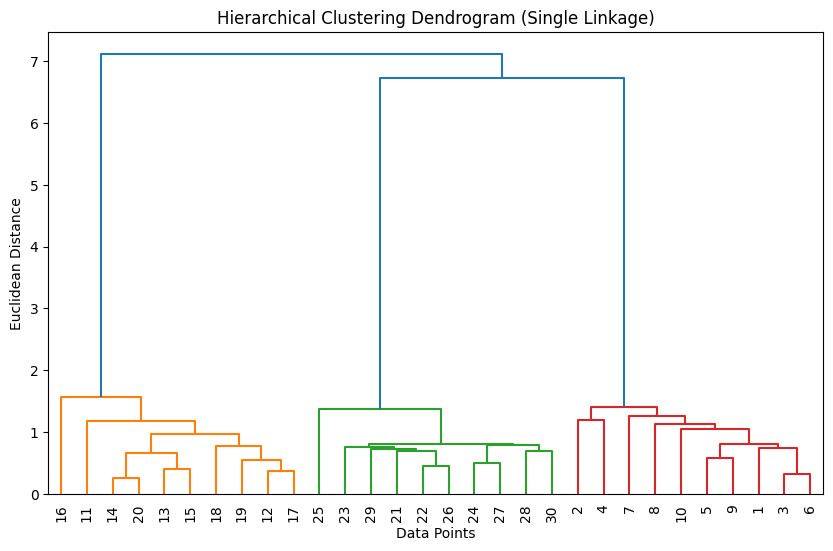

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Step 1: Generate points from Gaussian distributions
np.random.seed(42)  # For reproducibility

# N([0, 0], I2×2)
points_1 = np.random.multivariate_normal([0, 0], np.eye(2), 10)

# N([10, 0], I2×2)
points_2 = np.random.multivariate_normal([10, 0], np.eye(2), 10)

# N([0, 10], I2×2)
points_3 = np.random.multivariate_normal([0, 10], np.eye(2), 10)

# Combine all points into a single array
points = np.vstack((points_1, points_2, points_3))

# Step 2: Perform hierarchical clustering using single linkage and Euclidean distance
linked = linkage(points, method='single', metric='euclidean')

# Step 3: Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, labels=range(1, 31), leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Single Linkage)')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()
